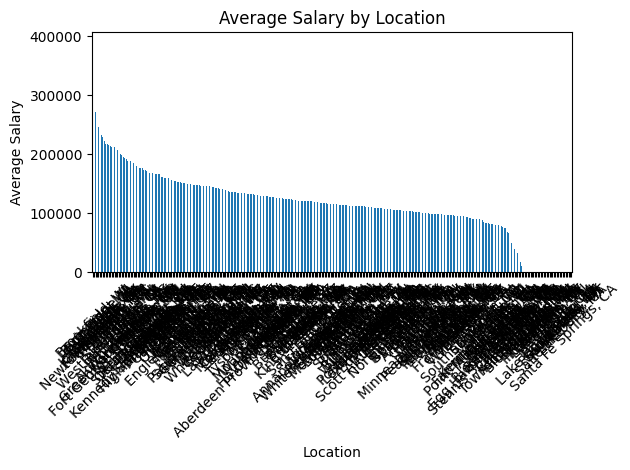

,Company,Company Score,Job Title,Location,Salary,Salary in Thousands,Company Score Category
0,ViewSoft,4.8,Software Engineer,"Manassas, VA",81000.0,81.0,Alta
1,Workiva,4.3,Software Support Engineer,Remote,82500.0,82.5,Alta
2,"Garmin International, Inc.",3.9,C# Software Engineer,"Cary, NC",106500.0,106.5,Média
3,Snapchat,3.5,"Software Engineer, Fullstack, 1+ Years of Expe...","Los Angeles, CA",121000.0,121.0,Média
4,Vitesco Technologies Group AG,3.1,Software Engineer,"Seguin, TX",96500.0,96.5,Média


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------------------------------
# Carregando o dataset
# --------------------------------------------------

df = pd.read_csv('job.csv')

df.head()


# --------------------------------------------------
# Tratamento da coluna Salary (formato Glassdoor)
# Exemplo: "68K - 94K (Glassdoor est.)"
# --------------------------------------------------

def clean_salary(salary):
    if pd.isna(salary):
        return None

    # Remove texto entre parênteses
    salary = re.sub(r'\(.*?\)', '', salary)

    # Remove espaços extras
    salary = salary.strip()

    # Extrai números do intervalo
    matches = re.findall(r'(\d+)', salary)

    if len(matches) >= 2:
        low = float(matches[0]) * 1000
        high = float(matches[1]) * 1000
        return (low + high) / 2

    return None

df['Salary'] = df['Salary'].apply(clean_salary)

df.head()


# --------------------------------------------------
# 1) Selecionar apenas a coluna Location
# --------------------------------------------------

df['Location'].head(10)


# --------------------------------------------------
# 2) Contar valores distintos em Location
# --------------------------------------------------

df['Location'].nunique()


# --------------------------------------------------
# 3) Criar coluna Salary in Thousands
# --------------------------------------------------

df['Salary in Thousands'] = df['Salary'] / 1000

df[['Salary', 'Salary in Thousands']].head()


# --------------------------------------------------
# 4) Filtragem Complexa
# California + salário maior que 150.000
# --------------------------------------------------

filtered_df = df[
    (df['Location'].str.contains('California|CA', na=False)) &
    (df['Salary'] > 150000)
]

filtered_df.head()


# --------------------------------------------------
# 5) Agrupamento e média salarial por Job Title
# --------------------------------------------------

salary_by_title = df.groupby('Job Title')['Salary'].mean()

salary_by_title.sort_values(ascending=False)


# --------------------------------------------------
# 6) Ordenar por Salary (decrescente)
# --------------------------------------------------

df.sort_values(by='Salary', ascending=False).head()


# --------------------------------------------------
# 7) Gráfico de barras - média salarial por Location
# --------------------------------------------------

location_salary = df.groupby('Location')['Salary'].mean().sort_values(ascending=False)

plt.figure()
location_salary.plot(kind='bar')
plt.title('Average Salary by Location')
plt.xlabel('Location')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 8) Pivot Table - média salarial por Location e Job Title
# --------------------------------------------------

pivot = pd.pivot_table(
    df,
    values='Salary',
    index='Location',
    columns='Job Title',
    aggfunc='mean'
)

pivot.head()


# --------------------------------------------------
# 9) Categorizar Company Score
# --------------------------------------------------

def categorize_score(score):
    if score >= 4:
        return 'Alta'
    elif score >= 3:
        return 'Média'
    else:
        return 'Baixa'

df['Company Score Category'] = df['Company Score'].apply(categorize_score)

df[['Company Score', 'Company Score Category']].head()


# --------------------------------------------------
# 10) Remover coluna Date
# --------------------------------------------------

df.drop(columns=['Date'], inplace=True)

df.head()